# 06 - ResNet50 Transfer Learning

This experiment uses ResNet50 pretrained on ImageNet. It follows the same data strategy used for the stronger baseline and transfer-learning runs:

- on-the-fly augmentation during training
- mild targeted oversampling on the training dataframe
- no class weights

This notebook trains only the frozen ResNet50 classifier head. Fine-tuning, if needed, should be done separately in `06B_resnet50_finetune.ipynb` after reviewing these results.

Current best candidate before this notebook:

- `efficientnetb0_aug_oversampled`
- accuracy about 0.9724
- macro F1 about 0.9565


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system


## 2. Imports and configuration

ResNet50 pretrained weights may be downloaded on the first run. If internet is unavailable, setting `PRETRAINED_WEIGHTS = None` will test the pipeline but is no longer a transfer-learning experiment.


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    SPLITS_DIR,
)
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.resnet50_model import build_resnet50_model
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "resnet50_aug_oversampled"
TARGET_MIN_COUNT = 500
PRETRAINED_WEIGHTS = "imagenet"

HEAD_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3

EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Input size:", IMAGE_SIZE)
print("Target minimum train count:", TARGET_MIN_COUNT)


I0000 00:00:1776676742.548476    6056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776676742.609822    6056 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776676768.466982    6056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: resnet50_aug_oversampled
Input size: (224, 224)
Target minimum train count: 500


## 3. Load split files and class names

If the split CSV files contain Windows paths such as `D:\\...`, the dataloader converts them to `/mnt/d/...` automatically when running under WSL.


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 20493 4392 4392
Classes: 28


## 4. Mild targeted oversampling

Only the training rows are oversampled. Validation and test remain untouched.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))
print("Added rows:", len(train_oversampled_df) - len(train_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
11,Grape__Rotten,140,500,360,3.57
10,Grape__Healthy,140,500,360,3.57
13,Guava__Rotten,140,500,360,3.57
12,Guava__Healthy,140,500,360,3.57
15,Jujube__Rotten,140,500,360,3.57
14,Jujube__Healthy,140,500,360,3.57
20,Pomegranate__Healthy,140,500,360,3.57
21,Pomegranate__Rotten,140,500,360,3.57
7,Carrot__Rotten,405,500,95,1.23
23,Potato__Rotten,409,500,91,1.22


Original train rows: 20493
Oversampled train rows: 24174
Added rows: 3681


## 5. Build TensorFlow datasets


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


I0000 00:00:1776676796.894155    6056 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build ResNet50 model

The dataloader returns `0..1` RGB images. The ResNet50 builder converts them internally to the BGR, ImageNet-centered format expected by Keras ResNet50.


In [6]:
augmentation = build_training_augmentation()
model = build_resnet50_model(
    num_classes=NUM_CLASSES,
    augmentation=augmentation,
    dropout_rate=0.4,
    train_base=False,
    weights=PRETRAINED_WEIGHTS,
)
model = compile_model(model, learning_rate=HEAD_LEARNING_RATE)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocess             │ (None, 224, 224, 3)    │             0 │
│ (ResNet50Preprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 28)             │        57,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,645,084 (90.20 MB)

 Trainable params: 57,372 (224.11 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. Train classifier head with frozen ResNet50 base


In [7]:
head_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_head_best.keras"

head_history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=HEAD_EPOCHS,
    checkpoint_path=head_checkpoint_path,
)


Epoch 1/8


I0000 00:00:1776676818.612159    6634 cuda_dnn.cc:461] Loaded cuDNN version 92100


418/756 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.6471 - loss: 1.2644

W0000 00:00:1776676880.414378    6780 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


446/756 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - accuracy: 0.6572 - loss: 1.2263

...

446/756 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - accuracy: 0.9688 - loss: 0.0956

W0000 00:00:1776677689.781158    9966 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


491/756 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.9688 - loss: 0.0958

W0000 00:00:1776677695.639271    9962 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


756/756 ━━━━━━━━━━━━━━━━━━━━ 113s 147ms/step - accuracy: 0.9665 - loss: 0.1013 - val_accuracy: 0.9731 - val_loss: 0.0961 - learning_rate: 0.0010


## 8. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate,stage
3,0.957971,0.128211,0.961749,0.121492,0.001,head
4,0.962025,0.110716,0.968579,0.102239,0.001,head
5,0.965955,0.106501,0.968352,0.113275,0.001,head
6,0.966038,0.101396,0.971311,0.099775,0.001,head
7,0.966493,0.101256,0.973133,0.096081,0.001,head


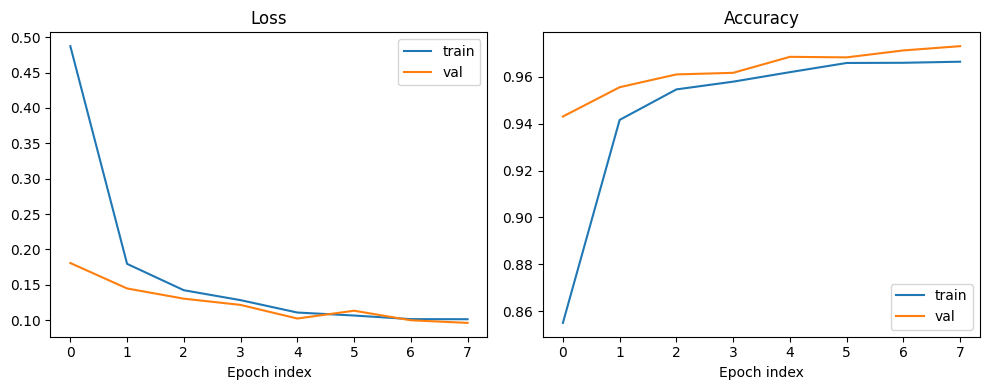

In [8]:
head_history_df = pd.DataFrame(head_history.history)
head_history_df["stage"] = "head"
history_df = head_history_df.copy()
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df.index, history_df["loss"], label="train")
plt.plot(history_df.index, history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch index")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df.index, history_df["accuracy"], label="train")
plt.plot(history_df.index, history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch index")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 9. Evaluate on test set


In [9]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


W0000 00:00:1776677756.463853   10406 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


,precision,recall,f1-score,support
Apple__Healthy,0.957560,0.989041,0.973046,365.000000
Apple__Rotten,0.990361,0.936219,0.962529,439.000000
Banana__Healthy,0.996678,1.000000,0.998336,300.000000
Banana__Rotten,1.000000,0.992840,0.996407,419.000000
Bellpepper__Healthy,0.966667,0.945652,0.956044,92.000000
Bellpepper__Rotten,0.806122,0.887640,0.844920,89.000000
Carrot__Healthy,1.000000,0.913978,0.955056,93.000000
Carrot__Rotten,0.913978,0.977011,0.944444,87.000000
Cucumber__Healthy,0.977778,0.967033,0.972376,91.000000
Cucumber__Rotten,0.955556,0.966292,0.960894,89.000000


Test accuracy: 0.9699
Macro F1: 0.9534
Weighted F1: 0.97


## 10. Focus on weak classes


In [10]:
weak_classes = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
    "Guava__Rotten",
    "Jujube__Rotten",
]

available_weak_classes = [name for name in weak_classes if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.987342,0.866667,0.923077,90.0
Bellpepper__Rotten,0.806122,0.887640,0.844920,89.0
Potato__Rotten,0.847059,0.827586,0.837209,87.0
Pomegranate__Rotten,0.909091,1.000000,0.952381,30.0
Carrot__Rotten,0.913978,0.977011,0.944444,87.0
Guava__Rotten,0.857143,1.000000,0.923077,30.0
Jujube__Rotten,0.906250,0.966667,0.935484,30.0


## 11. Compare with saved reports


In [11]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "baseline_aug_oversampled": FIGURES_DIR / "baseline_cnn_aug_oversampled_classification_report.csv",
    "mobilenetv2_frozen": FIGURES_DIR / "mobilenetv2_aug_oversampled_classification_report.csv",
    "mobilenetv2_finetuned_wsl": FIGURES_DIR / "mobilenetv2_aug_oversampled_finetuned_wsl_classification_report.csv",
    "efficientnetb0_frozen": FIGURES_DIR / "efficientnetb0_aug_oversampled_classification_report.csv",
    "efficientnetb0_finetuned_wsl": FIGURES_DIR / "efficientnetb0_aug_oversampled_finetuned_wsl_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.755464,0.700839,0.744463
1,baseline_aug_oversampled,0.756148,0.721686,0.756913
2,mobilenetv2_frozen,0.952413,0.925232,0.952505
3,mobilenetv2_finetuned_wsl,0.960383,0.936830,0.960243
4,efficientnetb0_frozen,0.972450,0.956472,0.972389
5,efficientnetb0_finetuned_wsl,0.977459,0.966409,0.977263
6,resnet50_aug_oversampled,0.969945,0.953391,0.970002


## 12. Confusion matrix


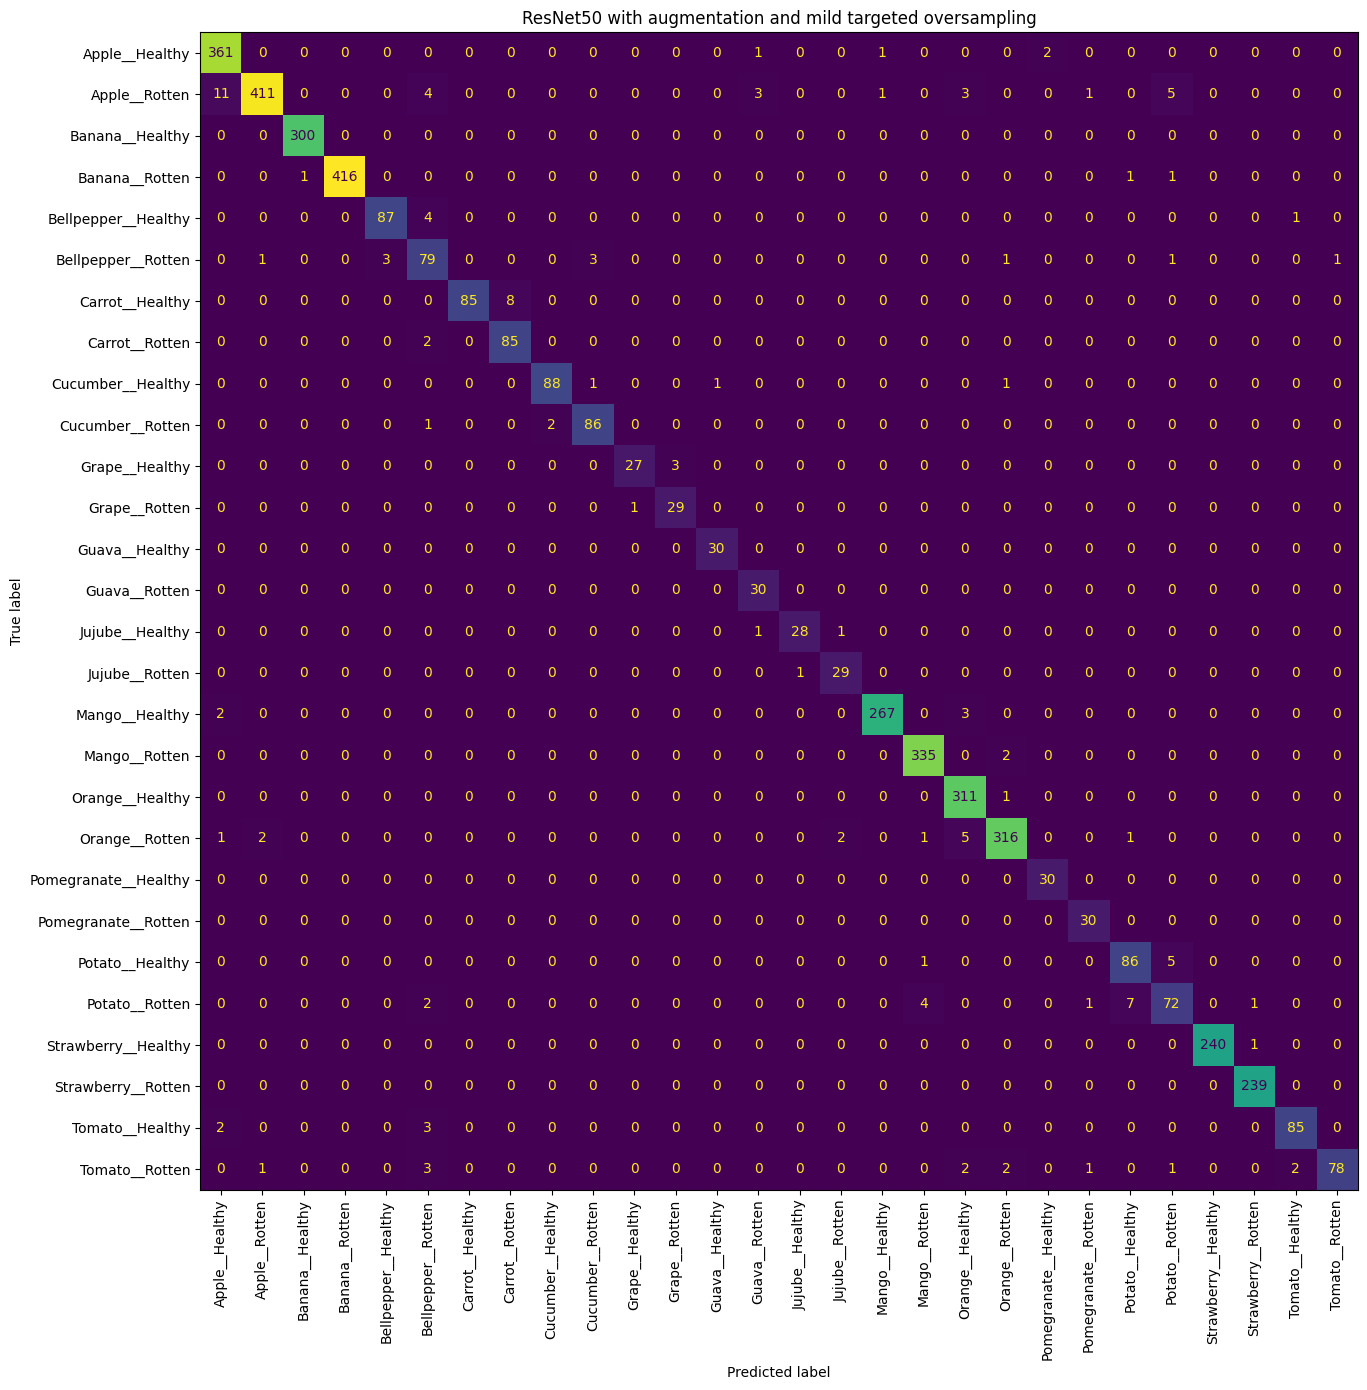

In [12]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("ResNet50 with augmentation and mild targeted oversampling")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 13. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. Select the final model only after comparing all candidates.


In [ ]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)
history_df.to_csv(FIGURES_DIR / f"{EXPERIMENT_NAME}_history.csv", index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "ResNet50",
    "pretrained_weights": PRETRAINED_WEIGHTS,
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "head_epochs_requested": HEAD_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "head_checkpoint": str(head_checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved oversampling summary:", oversampling_summary_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled.keras
Saved metadata: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled_metadata.json
Saved oversampling summary: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/resnet50_aug_oversampled_oversampling_summary.csv
Did not overwrite models/best_model.keras


: 

## 14. Decision rule

Use ResNet50 mainly as the final comparison model. Fine-tune it only if the frozen version is close to EfficientNetB0, improves specific weak rotten-class metrics, or gives evidence worth discussing in the report.

If frozen ResNet50 is clearly worse than EfficientNetB0, keep the result as comparison evidence and move to final model selection, XAI, and API work instead of spending more time on `06B`.
